# Checkpoint 5 — Derivadas, Mínimos Quadrados e Otimização

## Projeto aplicado de modelagem matemática

Dando continuidade à linha de raciocínio do Checkpoint 4, este notebook constrói um modelo matemático aproximado para o desempenho de um serviço de processamento de imagens, só que agora o "vilão" não é mais uma assíntota vertical, e sim um pool de **workers** que, em excesso, atrapalha mais do que ajuda. A ideia continua sendo a mesma: pegar dados experimentais, transformar em modelo, usar cálculo para entender o comportamento e chegar numa recomendação técnica que faça sentido.

Aqui o ajuste não é mais feito "no olho" com uma função escolhida à mão — usamos mínimos quadrados para ajustar um polinômio de grau 2 aos 12 pontos do teste de carga, e depois derivadas para localizar onde o throughput para de crescer e começa a cair.

> **Contexto:** um serviço de processamento de imagens é atendido por um pool de workers. Aumentar o número de workers melhora o throughput até certo ponto; depois disso, troca de contexto, contenção por memória e disputa por recursos compartilhados fazem o throughput cair. A equipe rodou um teste de carga variando o número de workers e mediu o throughput sustentado (req/s) em cada configuração.

### Organização

1. Contexto e dados do problema
2. Variáveis e domínios
3. Construção do modelo por mínimos quadrados
4. Análise algébrica utilizando derivadas
5. Máximos, mínimos e decisão de otimização
6. Implementação computacional e análise gráfica
7. Sensibilidade, interpretação e limitações
8. Conclusão


## Identificação do grupo

Seguindo o padrão pedido pela disciplina, a célula abaixo identifica quem participou deste Checkpoint. É o mesmo grupo do Checkpoint 4.


In [ ]:
# @title Identificacao
Nome_1 = "Kaick Lima Silva" # @param {type:"string"}
RM_1 = "574060" # @param {type:"string"}
Nome_2 = "Gustavo Basso" # @param {type:"string"}
RM_2 = "572623" # @param {type:"string"}
Nome_3 = "Guilherme Salles" # @param {type:"string"}
RM_3 = "572933" # @param {type:"string"}
Nome_4 = "Pedro Feltrin" # @param {type:"string"}
RM_4 = "569038" # @param {type:"string"}
Nome_5 = "Guilherme Kozikoski" # @param {type:"string"}
RM_5 = "571611" # @param {type:"string"}

integrantes = [
    (Nome_1, RM_1),
    (Nome_2, RM_2),
    (Nome_3, RM_3),
    (Nome_4, RM_4),
    (Nome_5, RM_5),
]

for nome, rm in integrantes:
    print(f"{nome} - RM {rm}")


Kaick Lima Silva - RM 574060
Gustavo Basso - RM 572623
Guilherme Salles - RM 572933
Pedro Feltrin - RM 569038
Guilherme Kozikoski - RM 571611


## 1. Contexto e dados fornecidos

Uma equipe de Engenharia de Software mantém um serviço de processamento de imagens disponibilizado por uma API. Para conseguir atender várias requisições ao mesmo tempo, a aplicação usa um **pool de workers** — em tese, quanto mais workers, mais requisições processadas em paralelo. O problema é que isso não é verdade indefinidamente: a partir de um certo ponto, o excesso de concorrência começa a gerar mais troca de contexto, contenção por memória, disputa por conexões e outros gargalos internos, e o throughput passa a cair em vez de subir.

Para investigar esse comportamento, a equipe rodou um teste de carga mantendo fixos a infraestrutura, o tamanho médio das imagens e o perfil das requisições, variando apenas o número de workers. Para cada configuração testada, foi medido o throughput sustentado (em requisições por segundo):

| Número de workers | Throughput observado (req/s) |
|---:|---:|
| 2 | 305 |
| 4 | 565 |
| 6 | 800 |
| 8 | 995 |
| 10 | 1140 |
| 12 | 1235 |
| 14 | 1285 |
| 16 | 1290 |
| 18 | 1245 |
| 20 | 1150 |
| 22 | 1010 |
| 24 | 850 |

Só de olhar a tabela já dá pra perceber o padrão: o throughput sobe, dá uma "acalmada" por volta de 14–16 workers, e depois começa a cair. Como qualquer teste de carga tem ruído experimental embutido, não faz sentido construir o modelo a partir de apenas 3 pontos escolhidos — vamos usar **todos** os 12 pontos e ajustar por **mínimos quadrados**.

**Questões orientadoras que guiam a análise:** qual função representa bem essa tendência? Em que configuração o modelo prevê o throughput máximo? Como a derivada descreve as regiões de ganho, saturação e degradação? O ótimo matemático contínuo pode ser usado diretamente, já que o número de workers precisa ser inteiro? E será que vale a pena operar um pouco abaixo do máximo para economizar recursos?

As dependências podem ser instaladas com o `requirements.txt`, copiando o comando abaixo no terminal:

```bash
pip install -r requirements.txt
```


In [ ]:
%pip install -r requirements.txt


In [ ]:
# Bibliotecas utilizadas no desenvolvimento do Projeto:
# - NumPy: ajuste polinomial (mínimos quadrados) e operações numéricas.
# - SymPy: definição simbólica da função ajustada, derivadas e pontos críticos.
# - Pandas: organização dos dados, resíduos e tabelas de resultados.
# - Matplotlib / Seaborn: construção dos gráficos de dispersão, ajuste, derivada e paleta viridis.
# Para instalar pela primeira vez no VsCode as seguintes bibliotecas,
# executar nessa celula os seguintes comandos %pip, e após isso, reiniciar a execução do notebook:
# (Aproximadamente 1 minuto de execução a 4 minutos de execução, dependendo da velocidade da internet e do computador)

"""%pip install numpy
%pip install sympy
%pip install pandas
%pip install matplotlib
%pip install seaborn
%pip install ipython"""

import numpy as np
import sympy as sp
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
PALETA = sns.color_palette("viridis", 8)


## 2. Definição das variáveis e dos domínios

Antes de sair ajustando curva, vale deixar claro o que cada símbolo representa:

- `w`: número de workers do pool — a variável independente. Na prática é sempre um número inteiro, mas vamos tratá-la como contínua no modelo matemático (isso facilita bastante a análise com derivadas, como veremos).
- `T(w)`: throughput previsto pelo modelo, em requisições processadas por segundo (req/s) — a variável dependente.

### Domínio matemático

O modelo escolhido é um polinômio de grau 2, `T(w) = a w² + b w + c`. Diferente do Checkpoint 4, aqui não existe divisão por zero nem nada parecido: um polinômio está definido para qualquer número real. Então o domínio matemático é simplesmente:

$$
D_{mat}=\mathbb{R}
$$

### Domínio operacional considerado

Só que "estar definido matematicamente" não é a mesma coisa que "fazer sentido no problema real". O teste de carga foi feito apenas entre 2 e 24 workers — fora dessa faixa não existe nenhuma medição que sustente o formato da parábola. Para `w` muito pequeno, o serviço praticamente não usa paralelismo algum; para `w` muito grande, o comportamento real do sistema operacional, do agendador de threads e da contenção de recursos pode ser bem diferente do que a parábola prevê (e note que uma parábola sempre volta a cair sem limite, o que certamente não corresponde à física real do sistema para `w` muito grande).

Por isso, na análise operacional deste checkpoint vamos trabalhar com:

$$
2\leq w\leq 24,\qquad w\in\mathbb{Z}^{+}\text{ na implantação real}
$$

Ou seja: o domínio matemático do polinômio é toda a reta real, mas o domínio que realmente importa para a decisão é o intervalo `[2, 24]`, que é onde existe evidência experimental. É a mesma ideia de distinguir domínio matemático de domínio operacional que já tínhamos discutido no Checkpoint 4, só que agora aplicada a um contexto diferente.


In [ ]:
# Base de dados fornecida no enunciado (número de workers x throughput observado).
dados = pd.DataFrame({
    "Workers (w)": [2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24],
    "Throughput observado (req/s)": [305, 565, 800, 995, 1140, 1235, 1285, 1290, 1245, 1150, 1010, 850],
})

dados


    Workers (w)  Throughput observado (req/s)
0             2                           305
1             4                           565
2             6                           800
3             8                           995
4            10                          1140
5            12                          1235
6            14                          1285
7            16                          1290
8            18                          1245
9            20                          1150
10           22                          1010
11           24                           850

### Gráfico de dispersão inicial

Antes de propor qualquer modelo, vale a pena simplesmente olhar para os dados. O gráfico abaixo mostra o throughput observado para cada configuração testada, sem nenhum ajuste ainda.

Dá para ver claramente: o throughput cresce enquanto o número de workers é pequeno, chega perto do topo em torno de 14 a 16 workers, e depois volta a cair conforme mais workers são adicionados. Isso é basicamente o retrato de uma **parábola com concavidade para baixo** — sobe, atinge um pico, desce de forma mais ou menos simétrica. Por isso um polinômio de grau 2 parece uma hipótese razoável aqui. Vale notar que esse comportamento é bem diferente do Checkpoint 4: lá tínhamos uma função racional com uma assíntota vertical (uma barreira que o sistema nunca conseguia ultrapassar); aqui não existe barreira nenhuma, existe sim um ponto de máximo *dentro* do próprio intervalo medido.


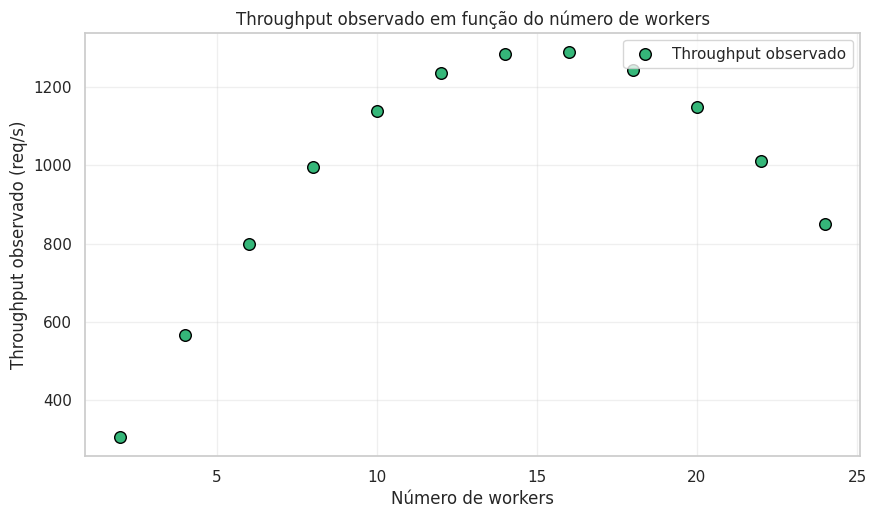

In [ ]:
# Gráfico de dispersão dos dados observados, sem ajuste.
w_dados = dados["Workers (w)"].to_numpy(dtype=float)
y_dados = dados["Throughput observado (req/s)"].to_numpy(dtype=float)

fig, ax = plt.subplots(figsize=(10, 5.5))

ax.scatter(w_dados, y_dados, s=70, color=PALETA[5], edgecolor="black", zorder=3, label="Throughput observado")

ax.set_title("Throughput observado em função do número de workers")
ax.set_xlabel("Número de workers")
ax.set_ylabel("Throughput observado (req/s)")
ax.grid(True, alpha=0.3)
ax.legend()

plt.show()


## 3. Construção do modelo por mínimos quadrados

O modelo escolhido é o polinômio de grau 2:

$$
T(w) = a w^{2} + b w + c
$$

em que `w` é o número de workers e `T(w)` é o throughput previsto (req/s). Só que os 12 pontos medidos não caem exatamente em cima de uma parábola — existe ruído experimental, como em qualquer teste de carga. Então os coeficientes `a`, `b` e `c` não são "escolhidos à mão": eles vêm do **método dos mínimos quadrados**. Para cada medição `(wᵢ, yᵢ)` definimos o resíduo `rᵢ = yᵢ − T(wᵢ)`, e o ajuste procura os coeficientes que minimizam a soma dos quadrados desses resíduos:

$$
S(a,b,c)=\sum_{i=1}^{n}\Big[y_i-\big(aw_i^{2}+bw_i+c\big)\Big]^{2}
$$

Em forma matricial, o problema vira `Xβ ≈ y`, com

$$
\beta=\begin{bmatrix}a\\ b\\ c\end{bmatrix},\qquad
X=\begin{bmatrix}w_1^2 & w_1 & 1\\ w_2^2 & w_2 & 1\\ \vdots & \vdots & \vdots\\ w_n^2 & w_n & 1\end{bmatrix}
$$

**Mas por que mínimos quadrados, e não simplesmente pegar 3 pontos e resolver o sistema exato?** Pensa assim: se escolhermos 3 pontos quaisquer e forçarmos a parábola a passar exatamente por eles (interpolação), estamos ignorando os outros 9 pontos medidos — e pior, se algum desses 3 pontos escolhidos tiver um desvio experimental um pouco maior que o normal, a parábola inteira muda de forma só para "obedecer" aquele ponto específico, mesmo que ele não represente bem a tendência real dos dados. O ajuste por mínimos quadrados evita esse problema porque usa os 12 pontos ao mesmo tempo, procurando os coeficientes que minimizam o erro total ao quadrado — ou seja, ele aceita um errinho pequeno em cada ponto individual em troca de representar melhor a tendência global. Interpolação garante erro zero em pontos escolhidos, mas não garante nada sobre o resto da curva; mínimos quadrados é exatamente o que se espera usar quando os dados vêm de um teste sujeito a variabilidade experimental, como é o nosso caso.


In [ ]:
# Ajuste por mínimos quadrados de um polinômio de grau 2.
# Duas formas equivalentes são utilizadas para o mesmo ajuste, como sugerido no enunciado:
# 1) numpy.polyfit
# 2) numpy.linalg.lstsq, com a matriz X explícita

w_arr = dados["Workers (w)"].to_numpy(dtype=float)
y_arr = dados["Throughput observado (req/s)"].to_numpy(dtype=float)

# 1) numpy.polyfit
a, b, c = np.polyfit(w_arr, y_arr, deg=2)

# 2) numpy.linalg.lstsq, deixando explícita a matriz X do problema
X = np.column_stack([
    w_arr**2,
    w_arr,
    np.ones_like(w_arr),
])
coeficientes, *_ = np.linalg.lstsq(X, y_arr, rcond=None)

print("Coeficientes via polyfit       -> a = %.6f | b = %.6f | c = %.6f" % (a, b, c))
print("Coeficientes via lstsq (X, y)  -> a = %.6f | b = %.6f | c = %.6f" % tuple(coeficientes))


Coeficientes via polyfit       -> a = -5.738012 | b = 174.013487 | c = -29.772727
Coeficientes via lstsq (X, y)  -> a = -5.738012 | b = 174.013487 | c = -29.772727


Os dois métodos batem exatamente nos mesmos coeficientes — o que já era esperado, já que resolvem o mesmo problema de mínimos quadrados por dois caminhos numéricos equivalentes. A função ajustada fica assim:

$$
\boxed{T(w) \approx -5{,}7380\,w^{2} + 174{,}0135\,w - 29{,}7727}
$$

**E o que o sinal do coeficiente `a` está dizendo?** `a ≈ -5,738` é negativo, o que significa concavidade para baixo. Faz todo sentido com o que vimos no gráfico: o throughput cresce, chega num pico e depois cai — exatamente o comportamento de uma parábola com `a<0`. Se por algum motivo `a` tivesse saído positivo, o modelo estaria prevendo o contrário (um "vale", concavidade para cima), o que obviamente não bateria com o padrão de crescimento-pico-queda que os dados mostram.


In [ ]:
# Cálculo dos valores previstos e dos resíduos para todas as medições.
dados_ajuste = dados.copy()
dados_ajuste["Throughput previsto (req/s)"] = a * w_arr**2 + b * w_arr + c
dados_ajuste["Resíduo (obs - previsto)"] = (
    dados_ajuste["Throughput observado (req/s)"] - dados_ajuste["Throughput previsto (req/s)"]
)

dados_ajuste = dados_ajuste.round(2)
dados_ajuste


    Workers (w)  ...  Resíduo (obs - previsto)
0             2  ...                      9.70
1             4  ...                     -9.47
2             6  ...                     -7.74
3             8  ...                     -0.10
4            10  ...                      3.44
5            12  ...                      2.88
6            14  ...                      3.23
7            16  ...                      4.49
8            18  ...                      1.65
9            20  ...                     -5.29
10           22  ...                    -11.33
11           24  ...                      8.54

[12 rows x 4 columns]

### Discussão dos resíduos

O maior resíduo em módulo aparece em `w=22`: o modelo prevê cerca de 1021,33 req/s, mas o valor observado foi 1010 req/s — uma diferença de aproximadamente -11,33 req/s, pouco mais de 1% do valor medido. Isso, sozinho, **não é motivo pra descartar o modelo**. É perfeitamente compatível com a variabilidade normal de um teste de carga (contenção momentânea de recursos, alguma variação de I/O, agendamento do sistema operacional...). E olha só o outro extremo: em `w=8` o resíduo é de apenas -0,10 req/s, praticamente em cima da curva.

Olhando o conjunto completo dos resíduos (`+9,7; -9,47; -7,74; -0,10; +3,44; +2,88; +3,23; +4,49; +1,65; -5,29; -11,33; +8,54`), não dá pra enxergar uma tendência clara — os sinais alternam, o que é um bom sinal. Um padrão sistemático (tipo, todos positivos na primeira metade e todos negativos na segunda) indicaria que o grau 2 está deixando escapar alguma coisa. Ainda assim, dá pra notar que entre `w=18` e `w=22` (na fase de queda) os pontos tendem a ficar um pouco abaixo da curva — um indício sutil de que a queda real pode ser levemente mais acentuada do que a queda simétrica que uma parábola pura consegue reproduzir. Não é grande coisa, mas vale registrar.

**E por que não extrapolar o modelo pra qualquer valor de `w`?** Porque o ajuste foi feito com dados entre `w=2` e `w=24` — fora dessa faixa a gente simplesmente não tem evidência de nada. Se levarmos a parábola longe o suficiente, ela vai continuar caindo até prever throughput negativo, o que evidentemente não existe fisicamente. É bem provável que o sistema real se estabilize em algum patamar mínimo (ou até quebre de outra forma) muito antes disso — mas o modelo não sabe nada sobre isso porque nunca viu dados nessa região. O mesmo vale pro outro lado: em `w=0` o modelo prevê `T(0)=c≈-29,77 req/s`, também negativo e sem sentido físico. Serve de lembrete de que o polinômio é uma aproximação local, válida só dentro (ou bem perto) do intervalo efetivamente testado.


## 4. Análise algébrica utilizando derivadas

### 4.1 Primeira derivada (cálculo algébrico)

A função ajustada é `T(w) = a w² + b w + c`. Usando a regra da potência (a derivada de `w^n` é `n·w^(n-1)`), a derivada de um polinômio de grau 2 é bem direta:

$$
T'(w) = 2aw + b
$$

Substituindo os coeficientes que obtivemos no ajuste (`a ≈ -5,7380`, `b ≈ 174,0135`):

$$
\boxed{T'(w) \approx -11{,}4760\,w + 174{,}0135}
$$

A célula de código abaixo refaz esse mesmo cálculo com SymPy — não porque precisássemos da ferramenta pra chegar no resultado (já fizemos à mão acima), mas pra confirmar que bateu certinho.


In [ ]:
# Construção simbólica de T(w), T'(w) e T''(w) com SymPy, a partir dos coeficientes do ajuste.
w = sp.symbols("w", real=True)

T = a * w**2 + b * w + c
dT = sp.diff(T, w)
d2T = sp.diff(T, w, 2)

print("T(w)   =", sp.N(T, 6))
print("T'(w)  =", sp.N(dT, 6))
print("T''(w) =", sp.N(d2T, 6))


T(w)   = -5.73801*w**2 + 174.013*w - 29.7727
T'(w)  = 174.013 - 11.476*w
T''(w) = -11.4760


### 4.2 Pontos críticos — resolução de `T'(w) = 0`

$$
-11{,}4760\,w + 174{,}0135 = 0 \quad\Longrightarrow\quad w^{*}=\frac{174{,}0135}{11{,}4760}
$$

Como `T'(w)` é uma reta (função do primeiro grau em `w`), só existe uma raiz — não tem mistério aqui, diferente de um caso onde a derivada fosse ela mesma um polinômio de grau maior. Resolvendo (e conferindo com SymPy logo abaixo):

$$
\boxed{w^{*}\approx 15{,}1632}
$$

Esse valor cai dentro do intervalo `[2, 24]`, que é o domínio que estamos considerando relevante — então ele é, de fato, candidato a máximo ou mínimo dentro da faixa analisada.


In [ ]:
# Resolução simbólica de T'(w) = 0.
pontos_criticos = sp.solve(sp.Eq(dT, 0), w)
w_estrela = float(pontos_criticos[0])
T_estrela = float(T.subs(w, w_estrela))

print("Ponto(s) crítico(s):", pontos_criticos)
print("w* =", round(w_estrela, 4))
print("T(w*) =", round(T_estrela, 4), "req/s")


Ponto(s) crítico(s): [15.1632208922742]
w* = 15.1632
T(w*) = 1289.5297 req/s


### 4.3 Análise de sinal de `T'(w)`

Como `T'(w) = -11,4760 w + 174,0135` é uma reta com coeficiente angular negativo, ela é decrescente o tempo todo e só troca de sinal uma vez, em `w = w* ≈ 15,1632`:

- Para `w < 15,1632`: `T'(w) > 0` → o modelo prevê throughput crescente — cada worker a mais ainda ajuda.
- Em `w = 15,1632`: `T'(w) = 0` → é o topo, a taxa de variação zera.
- Para `w > 15,1632`: `T'(w) < 0` → throughput decrescente — a partir daqui, cada worker a mais atrapalha mais do que ajuda.

Traduzindo em linguagem de engenharia:

- **Derivada positiva** → adicionar um worker aumenta o throughput previsto. É a região de **ganho de desempenho**.
- **Derivada nula** → não há ganho nem perda marginal; é o ponto de transição, o pico previsto pelo modelo. Região de **saturação**.
- **Derivada negativa** → adicionar um worker reduz o throughput. Região de **degradação** — o excesso de concorrência já está superando qualquer ganho de paralelismo.


In [ ]:
# Cálculo de T'(w) em pontos específicos do domínio, com a unidade correta:
# requisições por segundo, por worker adicional (req/s por worker).
pontos_avaliados = [8, 12, 16, 20]

derivadas = pd.DataFrame({
    "w": pontos_avaliados,
    "T'(w) [req/s por worker]": [round(float(dT.subs(w, wi)), 4) for wi in pontos_avaliados],
})

derivadas


    w  T'(w) [req/s por worker]
0   8                   82.2053
1  12                   36.3012
2  16                   -9.6029
3  20                  -55.5070

### 4.4 Comparando `T'(8)`, `T'(12)`, `T'(16)` e `T'(20)`

| `w` | `T'(w)` (req/s por worker) | O que isso significa |
|---:|---:|---|
| 8  | +82,21 | Ganho forte — cada worker adicional ainda entrega bastante throughput extra. |
| 12 | +36,30 | Ganho já mais moderado, o serviço está se aproximando da saturação, mas ainda vale a pena adicionar workers. |
| 16 | -9,60  | Já passou do pico (`w*≈15,16`) — aqui adicionar workers começa a reduzir o throughput. |
| 20 | -55,51 | Degradação bem acentuada. Nessa configuração o sistema está claramente super-provisionado; tirar alguns workers ajudaria mais do que manter todos eles. |

Repare como a magnitude da derivada cai de forma constante e linear conforme `w` aumenta (afinal a taxa de variação da derivada é a segunda derivada, que é constante) — indo de fortemente positiva em `w=8`, passando por levemente negativa em `w=16`, até fortemente negativa em `w=20`. É essa progressão que quantifica, em números, a transição entre ganho → saturação → degradação que já dava pra intuir só olhando os dados brutos.


### 4.5 Segunda derivada e concavidade

Derivando `T'(w) = 2aw + b` mais uma vez:

$$
T''(w) = 2a \approx -11{,}4760
$$

Como `T''(w)` é constante e negativa em todo o domínio (na verdade em toda a reta real — é uma parábola, então isso vale sempre), a função `T(w)` tem concavidade voltada para baixo o tempo inteiro. Isso confirma que existe um único ponto de máximo global, sem ponto de inflexão nenhum e sem outro candidato a extremo escondido em algum lugar: uma vez que encontramos o único ponto onde `T'(w)=0`, a segunda derivada já garante que ele é um máximo, e não um mínimo nem um ponto de sela.


In [ ]:
# Valor numérico da segunda derivada (constante).
valor_d2T = float(d2T)
print("T''(w) =", round(valor_d2T, 4), "(constante, negativa em todo o domínio)")


T''(w) = -11.476 (constante, negativa em todo o domínio)


### Questão obrigatória (seção 4.2)

**O número de workers é discreto na implantação real. Por que ainda faz sentido construir e derivar um modelo contínuo `T(w)`? Depois de encontrar um ponto crítico não inteiro, quais verificações devem ser feitas antes de recomendar uma configuração?**

Mesmo `w` sendo discreto na prática (não dá pra rodar o serviço com "15,16 workers"), trabalhar com um modelo contínuo compensa porque o cálculo diferencial só é definido para funções contínuas — é justamente a derivada que permite localizar, de forma exata e analítica, onde o throughput cresce, onde ele estaciona e onde ele cai, em vez de precisar testar manualmente as 23 configurações inteiras possíveis uma por uma. O modelo contínuo funciona como uma aproximação suave de um fenômeno que, na vida real, é discreto — e é bem mais fácil derivar, resolver `T'(w)=0` e classificar o extremo algebricamente do que ficar "chutando" a partir de uma tabela de pontos.

Só que encontrar um ponto crítico não inteiro (`w*≈15,16`) não é o fim da história. Antes de recomendar qualquer configuração, é preciso:

1. Confirmar que esse ponto está dentro do domínio operacional relevante (`2 ≤ w ≤ 24`) — o que de fato acontece aqui;
2. Classificar o ponto (feito acima: é um máximo, porque `T''<0`);
3. Arredondar para os inteiros vizinhos (`w=15` e `w=16`) e comparar o throughput previsto de cada um, escolhendo o melhor;
4. Comparar com os valores observados na tabela original nessa vizinhança, pra checar se a recomendação bate com o que já foi medido de fato;
5. Lembrar que, no fim das contas, é um modelo aproximado — antes de mudar qualquer coisa em produção, o ideal é validar a configuração recomendada com um novo teste de carga controlado, em vez de confiar cegamente no número contínuo.


## 5. Máximos, mínimos e decisão de otimização

### 5.1 Classificação do ponto crítico

O ponto crítico que encontramos é `w* ≈ 15,1632`, com `T(w*) ≈ 1289,53` req/s.

**Pelo teste da primeira derivada:** já vimos que `T'(w)>0` antes de `w*` e `T'(w)<0` depois — a função passa de crescente pra decrescente exatamente nesse ponto. Isso já classifica `w*` como um ponto de máximo local.

**Confirmando com a segunda derivada:** `T''(w) = 2a ≈ -11,4760`, negativa para qualquer `w`. Segundo o Teste da Segunda Derivada, isso confirma que `w*` é mesmo um ponto de máximo (e não algum outro tipo de ponto crítico).

### 5.2 Comparando com as extremidades do domínio `[2, 24]`

Só que, num intervalo fechado, o máximo e o mínimo absolutos não precisam estar necessariamente num ponto crítico — podem estar nas bordas do intervalo também. Então vamos comparar os três candidatos possíveis:


In [ ]:
# Comparação entre o ponto crítico e as extremidades do domínio operacional [2, 24].
candidatos = pd.DataFrame({
    "Ponto": ["Extremidade w=2", "Ponto crítico w*≈15,16", "Extremidade w=24"],
    "w": [2, round(w_estrela, 4), 24],
    "T(w) previsto (req/s)": [
        round(float(T.subs(w, 2)), 2),
        round(T_estrela, 2),
        round(float(T.subs(w, 24)), 2),
    ],
})

candidatos


                    Ponto        w  T(w) previsto (req/s)
0         Extremidade w=2   2.0000                 295.30
1  Ponto crítico w*≈15,16  15.1632                1289.53
2        Extremidade w=24  24.0000                 841.46

Com `T(2) ≈ 295,30`, `T(w*) ≈ 1289,53` e `T(24) ≈ 841,46`, fica claro: o **máximo absoluto** no intervalo `[2, 24]` está no ponto crítico `w* ≈ 15,16`, e o **mínimo absoluto** está na extremidade `w=2`.

Vale explicar a diferença entre local e absoluto aplicada a este problema específico:

- **Máximo local:** um ponto onde o throughput é maior que nos pontos vizinhos imediatos. Como a função é uma parábola (só tem um "morro"), o único máximo local que existe já é também o máximo absoluto — não tem mais nenhum escondido em outro lugar.
- **Máximo absoluto:** o maior valor de `T(w)` em todo o intervalo `[2,24]` analisado — que é `T(w*)≈1289,53` req/s.
- **Mínimo local:** aqui simplesmente não existe um mínimo local *dentro* do intervalo (a parábola não tem "vale"). Os únicos candidatos a mínimo são as próprias extremidades.
- **Mínimo absoluto:** o menor valor de `T(w)` no intervalo, que é `T(2)≈295,30` req/s. Faz sentido: `w=2` é o ponto mais distante do pico, e com poucos workers o serviço ainda está bem sub-provisionado.

Isso mostra bem por que a análise de extremos num intervalo fechado não pode ignorar as extremidades: se o domínio fosse toda a reta real, a parábola nem teria mínimo algum (ela cai sem parar conforme `w→±∞`). É justamente por restringirmos a análise ao intervalo `[2,24]` — que é a faixa que efetivamente testamos — que faz sentido falar em "mínimo absoluto" aqui.


In [ ]:
# Avaliação dos inteiros vizinhos ao ótimo contínuo.
import math

w_inf = math.floor(w_estrela)
w_sup = math.ceil(w_estrela)

vizinhos = pd.DataFrame({
    "w (inteiro)": [w_inf, w_sup],
    "T(w) previsto (req/s)": [
        round(float(T.subs(w, w_inf)), 2),
        round(float(T.subs(w, w_sup)), 2),
    ],
})

w_otimo_inteiro = w_inf if float(T.subs(w, w_inf)) >= float(T.subs(w, w_sup)) else w_sup
T_otimo_inteiro = float(T.subs(w, w_otimo_inteiro))

diferenca_continuo_inteiro = T_estrela - T_otimo_inteiro

print(vizinhos.to_string(index=False))
print()
print(f"Configuração inteira ótima: w = {w_otimo_inteiro} workers, T(w) ≈ {T_otimo_inteiro:.2f} req/s")
print(f"Diferença entre o máximo contínuo e a configuração inteira ótima: {diferenca_continuo_inteiro:.4f} req/s")

# Menor configuração inteira que alcança pelo menos 99% do throughput máximo contínuo.
limiar_99 = 0.99 * T_estrela
w_quase_otimo = None
for wi in range(2, 25):
    valor = float(T.subs(w, wi))
    if valor >= limiar_99:
        w_quase_otimo = wi
        T_quase_otimo = valor
        break

print()
print(f"Limiar de 99% do throughput máximo contínuo: {limiar_99:.2f} req/s")
print(f"Menor configuração inteira que atinge >= 99% do máximo: w = {w_quase_otimo}, T(w) ≈ {T_quase_otimo:.2f} req/s")


 w (inteiro)  T(w) previsto (req/s)
          15                1289.38
          16                1285.51

Configuração inteira ótima: w = 15 workers, T(w) ≈ 1289.38 req/s
Diferença entre o máximo contínuo e a configuração inteira ótima: 0.1529 req/s

Limiar de 99% do throughput máximo contínuo: 1276.63 req/s
Menor configuração inteira que atinge >= 99% do máximo: w = 14, T(w) ≈ 1281.77 req/s


### 5.3 Ótimo contínuo, ótimo inteiro e configuração "quase ótima"

O ótimo contínuo (`w*≈15,16`) não dá pra implementar diretamente, já que o número de workers precisa ser inteiro. Comparando os dois inteiros mais próximos: `w=15` entrega `T(15)≈1289,38` req/s, e `w=16` entrega `T(16)≈1285,51` req/s. Então `w=15` vence e vira a configuração inteira ótima — e olha que a diferença pro valor contínuo é minúscula, cerca de 0,15 req/s (menos de 0,02%). Isso acontece porque `w*` está bem colado em `15`, e porque a região ao redor do vértice de uma parábola é bem plana (a derivada já está próxima de zero por ali — `T'(15)≈1,87` e `T'(16)≈-9,60`, ambas pequenas).

E tem mais uma opção interessante: a configuração "quase ótima", que é o menor `w` inteiro capaz de entregar pelo menos 99% do throughput máximo contínuo. Esse ponto é `w=14`, com `T(14)≈1281,77` req/s. Pensa no trade-off: usar 14 workers em vez de 15 é uma redução de quase 7% no número de workers provisionados, e o throughput perdido é menor que 1%. Numa situação real, onde cada worker custa memória, CPU e dinheiro de infraestrutura, essa é uma informação com peso — a equipe pode preferir `w=14` justamente para economizar recursos, sabendo exatamente o quanto está abrindo mão de desempenho.

E como isso se compara com o que foi de fato observado no teste? O maior throughput medido experimentalmente foi `1290 req/s`, em `w=16` — bem perto do que o modelo prevê tanto para `w=15` (`≈1289,38`) quanto para `w=16` (`≈1285,51`). O modelo capta bem essa região, mesmo que o pico observado (`w=16`) não seja exatamente igual ao pico previsto pelo ajuste (`w*≈15,16`); é uma diferença pequena e até esperada, já que o ajuste considera os 12 pontos, não só o maior valor medido.

Por que adicionar workers pra sempre não aumenta o throughput pra sempre? Os próprios dados (e o modelo) mostram que, passado certo ponto, o custo de coordenar todos esses workers — troca de contexto, contenção de memória, disputa por conexões e recursos compartilhados — cresce mais rápido do que qualquer ganho de paralelismo que eles trariam. É exatamente isso que a derivada negativa está capturando: cada worker além do ponto de saturação tira throughput, não adiciona. No fim das contas existe um número finito de núcleos de CPU, de banda de I/O e de conexões úteis; workers além dessa capacidade só ficam competindo entre si, sem agregar processamento real.


### Questão obrigatória (seção 4.3)

**Resolver `T'(w)=0` é suficiente para afirmar que o ponto encontrado é o ótimo do problema? Explique o papel da análise de sinal, da segunda derivada, do domínio, das extremidades do intervalo e da natureza discreta da decisão.**

Não, sozinho não basta. Resolver `T'(w)=0` só encontra um ponto crítico — um candidato a extremo. Não diz se é máximo, mínimo, ou nem uma coisa nem outra (em funções mais complexas até poderia ser um ponto de inflexão com derivada horizontal). Pra afirmar que é de fato um ótimo, é preciso complementar com mais algumas verificações:

- **Análise de sinal de `T'(w)`** (Teste da Primeira Derivada): ver se a derivada troca de positiva pra negativa (máximo), de negativa pra positiva (mínimo), ou nem troca de sinal (nem uma coisa nem outra) ao redor do ponto crítico;
- **Segunda derivada**: `T''(w)<0` confirma concavidade pra baixo, logo máximo; `T''(w)>0` indicaria mínimo. Aqui `T''(w)` é constante e negativa, o que já confirma o máximo de cara;
- **O domínio considerado**: um ponto crítico só interessa se estiver dentro do intervalo que faz sentido pro problema. Se `w*` tivesse caído fora de `[2,24]`, ele seria matematicamente um máximo da parábola, mas não uma recomendação operacional válida;
- **As extremidades do intervalo**: num domínio fechado, o máximo e o mínimo absolutos podem estar nas bordas, não só em pontos críticos internos — por isso comparamos `T(2)`, `T(w*)` e `T(24)` explicitamente, em vez de confiar cegamente no ponto crítico;
- **A natureza discreta da decisão**: mesmo sabendo que `w*` é o máximo contínuo, a decisão final precisa levar em conta que `w` tem que ser inteiro — daí a comparação entre os inteiros vizinhos e, neste projeto, também a configuração de 99%, antes de chegar num valor de fato implementável.

Em resumo: `T'(w)=0` é só o primeiro passo de uma sequência de verificações. Ele localiza candidatos, mas classificar, comparar com as bordas e adaptar pra um número inteiro são etapas igualmente necessárias pra sustentar a decisão técnica.


### Decisão técnica obrigatória

**A recomendação da equipe para o próximo teste controlado é `w = 15` workers.**

Justificando, comparando explicitamente tudo que é pedido:

- **Máximo contínuo:** o pico teórico do modelo está em `w* ≈ 15,16` workers, com `T(w*) ≈ 1289,53` req/s — mas esse valor, por si só, não dá pra implementar, já que `w` precisa ser inteiro.
- **Ótimo inteiro:** entre os inteiros vizinhos, `w=15` entrega `T(15)≈1289,38` req/s, superando `w=16` (`T(16)≈1285,51`) e ficando a menos de 0,15 req/s do pico contínuo — uma diferença que, na prática, não importa.
- **Configuração "quase ótima" (99%):** `w=14` já entrega `T(14)≈1281,77` req/s, mais de 99% do máximo previsto, usando um worker a menos. É uma alternativa válida se a prioridade for economizar recursos em vez de espremer o último req/s de throughput.
- **Dados observados:** o maior throughput medido de fato no teste (`1290 req/s`) ocorreu em `w=16`, bem perto — tanto em `w` quanto em throughput — da recomendação do modelo. Isso dá um respaldo empírico extra à faixa `w∈{14,15,16}` como a região de melhor desempenho, mesmo com essa pequena diferença entre o pico observado (`w=16`) e o pico previsto (`w≈15`).
- **Limitações do modelo:** o ajuste vem de apenas 12 medições, sujeitas a ruído experimental normal de qualquer teste de carga. A diferença entre `w=15` e `w=16` é pequena o suficiente pra estar dentro da margem de incerteza do próprio ajuste (os resíduos observados são da ordem de poucos req/s). Por isso a recomendação final não deve ser encarada como um número "cravado", e sim como o centro de uma faixa recomendada, de `14` a `16` workers, a ser confirmada com um novo teste de carga controlado antes de qualquer mudança definitiva em produção.

Na prática, a recomendação é começar o próximo teste controlado em `w=15` workers, com `w=14` como alternativa "quase ótima" caso o foco seja economia de recursos, e `w=16` como referência por ser a configuração com o maior throughput já medido de fato.


## 6. Implementação computacional e análise gráfica

Nesta seção juntamos tudo em tabelas e gráficos: primeiro uma tabela com `T(w)` e `T'(w)` para todos os valores inteiros de `w` entre 2 e 24, depois os dois gráficos pedidos — um mostrando os dados experimentais junto com a curva ajustada (destacando o ótimo contínuo, o ótimo inteiro e a configuração de 99%), e outro mostrando a derivada `T'(w)`, com destaque para onde ela cruza o zero.


In [ ]:
# Tabela de T(w) e T'(w) para todos os valores inteiros de w entre 2 e 24.
w_inteiros = list(range(2, 25))

tabela_completa = pd.DataFrame({
    "w": w_inteiros,
    "T(w) previsto (req/s)": [round(float(T.subs(w, wi)), 2) for wi in w_inteiros],
    "T'(w) (req/s por worker)": [round(float(dT.subs(w, wi)), 2) for wi in w_inteiros],
})

tabela_completa


     w  T(w) previsto (req/s)  T'(w) (req/s por worker)
0    2                 295.30                    151.06
1    3                 440.63                    139.59
2    4                 574.47                    128.11
3    5                 696.84                    116.63
4    6                 807.74                    105.16
5    7                 907.16                     93.68
6    8                 995.10                     82.21
7    9                1071.57                     70.73
8   10                1136.56                     59.25
9   11                1190.08                     47.78
10  12                1232.12                     36.30
11  13                1262.68                     24.83
12  14                1281.77                     13.35
13  15                1289.38                      1.87
14  16                1285.51                     -9.60
15  17                1270.17                    -21.08
16  18                1243.35                   

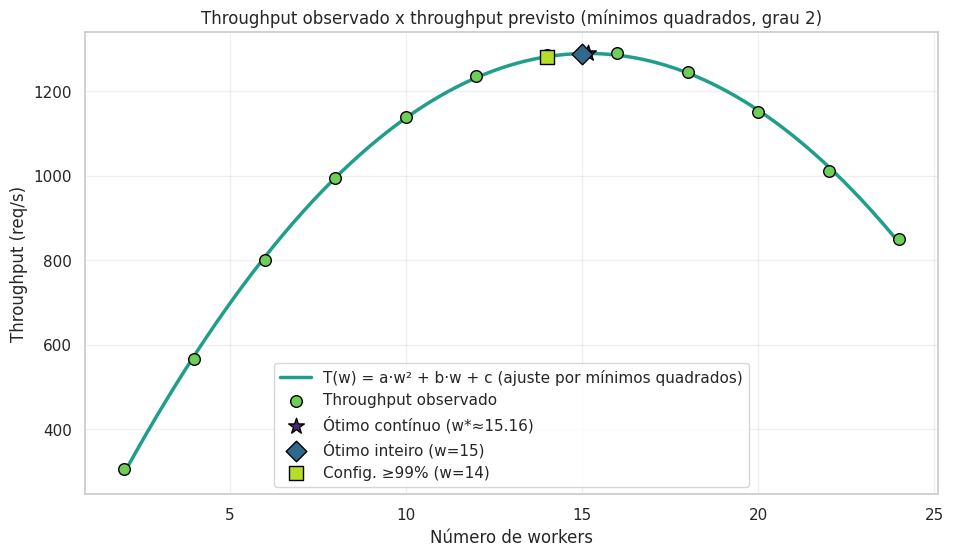

In [ ]:
# Gráfico 1: dados experimentais, curva ajustada e destaques
# (ótimo contínuo, ótimo inteiro e configuração de 99%).
w_plot = np.linspace(2, 24, 400)
y_plot = a * w_plot**2 + b * w_plot + c

fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(w_plot, y_plot, color=PALETA[4], linewidth=2.5,
        label="T(w) = a·w² + b·w + c (ajuste por mínimos quadrados)")

ax.scatter(w_arr, y_arr, s=70, color=PALETA[6], edgecolor="black", zorder=4,
           label="Throughput observado")

ax.scatter([w_estrela], [T_estrela], s=140, marker="*", color=PALETA[0],
           edgecolor="black", zorder=5, label=f"Ótimo contínuo (w*≈{w_estrela:.2f})")

ax.scatter([w_otimo_inteiro], [T_otimo_inteiro], s=110, marker="D", color=PALETA[2],
           edgecolor="black", zorder=5, label=f"Ótimo inteiro (w={w_otimo_inteiro})")

ax.scatter([w_quase_otimo], [T_quase_otimo], s=110, marker="s", color=PALETA[7],
           edgecolor="black", zorder=5, label=f"Config. ≥99% (w={w_quase_otimo})")

ax.set_title("Throughput observado x throughput previsto (mínimos quadrados, grau 2)")
ax.set_xlabel("Número de workers")
ax.set_ylabel("Throughput (req/s)")
ax.grid(True, alpha=0.3)
ax.legend(loc="lower center")

plt.show()


**Sobre o Gráfico 1:** a curva ajustada acompanha os pontos observados bem de perto em quase todo o intervalo, o que já confirma visualmente que o ajuste por mínimos quadrados ficou bom. O ótimo contínuo (estrela), o ótimo inteiro (losango, `w=15`) e a configuração de 99% (quadrado, `w=14`) aparecem todos bem juntinhos, no topo da curva — o que reforça algo que já tínhamos comentado: essa região é relativamente plana, então pequenas mudanças em `w` por ali não fazem muita diferença no throughput previsto. Já nas bordas do intervalo (`w` bem pequeno ou bem grande), a curva fica bem mais inclinada, o que mostra que nessas regiões mudar o número de workers tem impacto bem maior sobre o desempenho.


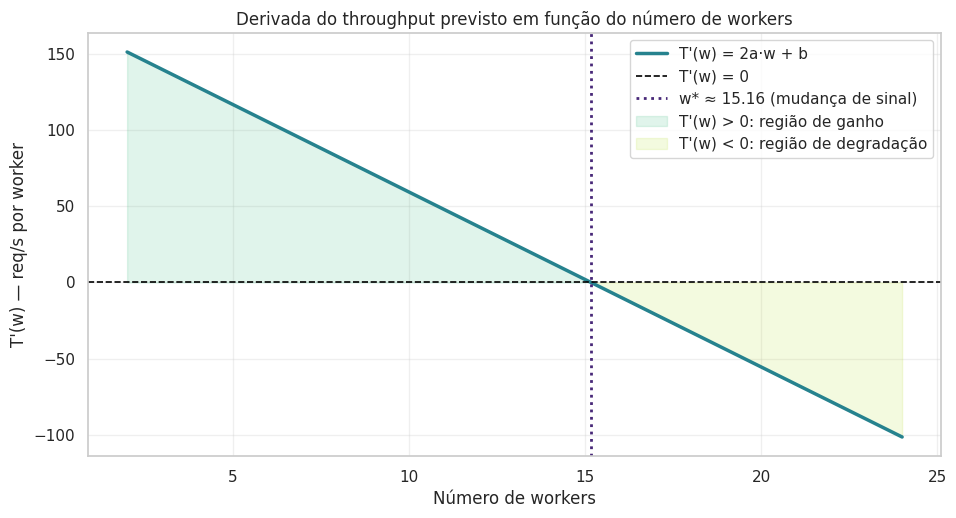

In [ ]:
# Gráfico 2: T'(w) no domínio analisado, com destaque para T'(w)=0
# e para a região de mudança de sinal (crescimento -> decrescimento).
w_plot2 = np.linspace(2, 24, 400)
dy_plot2 = 2 * a * w_plot2 + b

fig, ax = plt.subplots(figsize=(11, 5.5))

ax.plot(w_plot2, dy_plot2, color=PALETA[3], linewidth=2.5, label="T'(w) = 2a·w + b")

ax.axhline(0, color="black", linestyle="--", linewidth=1.2, label="T'(w) = 0")

ax.axvline(w_estrela, color=PALETA[0], linestyle=":", linewidth=2,
           label=f"w* ≈ {w_estrela:.2f} (mudança de sinal)")

ax.fill_between(w_plot2, dy_plot2, 0, where=(w_plot2 < w_estrela),
                color=PALETA[5], alpha=0.15, label="T'(w) > 0: região de ganho")

ax.fill_between(w_plot2, dy_plot2, 0, where=(w_plot2 >= w_estrela),
                color=PALETA[7], alpha=0.15, label="T'(w) < 0: região de degradação")

ax.set_title("Derivada do throughput previsto em função do número de workers")
ax.set_xlabel("Número de workers")
ax.set_ylabel("T'(w) — req/s por worker")
ax.grid(True, alpha=0.3)
ax.legend(loc="upper right")

plt.show()


**Sobre o Gráfico 2:** a reta de `T'(w)` é decrescente e cruza o eixo horizontal exatamente em `w*≈15,16`, dividindo o domínio em duas regiões: à esquerda `T'(w)>0` (a região de ganho, sombreada), onde cada worker a mais ainda aumenta o throughput previsto; à direita `T'(w)<0` (a região de degradação, sombreada em outra cor), onde cada worker a mais já reduz o throughput. É basicamente a versão gráfica de toda a análise de sinal que fizemos algebricamente na Seção 4.

### Investigação computacional

Vale comparar o maior valor observado na tabela (`w=16`, `y=1290 req/s`) com o máximo previsto pelo modelo (`w*≈15,16`, `T(w*)≈1289,53 req/s`): os dois estão bem próximos, tanto em `w` (menos de 1 worker de diferença) quanto em throughput (menos de 1 req/s de diferença). Eles não coincidem exatamente, mas isso **não invalida** o ajuste — pelo contrário, é o comportamento esperado. O ajuste usa os 12 pontos pra minimizar o erro total, não apenas pra "acertar" o ponto de maior valor observado. Se o pico do modelo caísse exatamente em cima do maior ponto medido, isso na verdade seria um sinal de alerta — indicaria que o ajuste está overfittando a um único ponto (possivelmente ruidoso), em vez de representar a tendência de todos os dados.

Outra coisa que dá pra notar é que a região perto do máximo é bem plana: como já vimos no Gráfico 2, `T'(w)` vai de `+1,87` em `w=15` para `-9,60` em `w=16` — valores pequenos em módulo, o que mostra que a curva "achata" bastante ao redor do pico. Isso tem uma consequência prática interessante: escolher entre `w=14`, `w=15` ou `w=16` não é uma decisão crítica em termos de throughput perdido (todas entregam valores muito próximos do máximo), então a equipe tem liberdade pra escolher a configuração com base em outros critérios — custo, consumo de memória, simplicidade operacional — sem abrir mão de desempenho de forma relevante.


## 7. Notebook técnico: sensibilidade, interpretação e limitações

### a) O que caracteriza matematicamente a região de saturação

A saturação aparece quando a derivada `T'(w)` se aproxima de zero: em `w=14`, `T'(14)≈13,35`; em `w=15`, `T'(15)≈1,87`; em `w=16`, `T'(16)≈-9,60`. A taxa de variação do throughput cai rapidamente pra perto de zero nessa faixa — é exatamente esse "achatamento" que caracteriza a saturação matematicamente, em contraste com os valores bem positivos da região de ganho (`T'(8)≈82,21`) e bem negativos da região de degradação (`T'(20)≈-55,51`).

### b) Por que o throughput cai com excesso de workers, do ponto de vista de Engenharia de Software

Os dados mostram a queda começando por volta de `w=16-18`. Isso bate com mecanismos bem conhecidos em sistemas concorrentes: **troca de contexto** excessiva quando muitos workers disputam o mesmo número (finito) de núcleos de CPU; **contenção por memória**, já que mais workers significam mais memória usada simultaneamente, podendo gerar swapping ou pressão no garbage collector dependendo da linguagem/runtime; **competição por conexões**, quando o pool de conexões com banco de dados ou outro storage compartilhado vira gargalo porque há mais workers do que conexões disponíveis; e **disputas por recursos compartilhados** em geral, como locks, filas internas e I/O em disco. No fim, todos esses fatores fazem o overhead de coordenar tantos workers crescer mais rápido do que o ganho real de paralelismo — e é justamente isso que a derivada negativa está quantificando.

### c) Ótimo contínuo x ótimo inteiro x configuração "quase ótima"

O ótimo contínuo (`w*≈15,16`) é puramente o resultado matemático de resolver `T'(w)=0` no polinômio — um valor teórico que não dá pra implementar diretamente. O ótimo inteiro (`w=15`) é o melhor valor que de fato pode ser usado, obtido comparando os inteiros vizinhos ao ótimo contínuo. Já a configuração "quase ótima" (`w=14`) é uma alternativa que abre mão de menos de 1% de throughput previsto pra usar um worker a menos — uma troca que o ótimo matemático puro não enxerga, mas que faz total sentido do ponto de vista de engenharia.

### d) Hipóteses do modelo que podem limitar sua validade fora do intervalo medido

O modelo assume, implicitamente, que o comportamento observado entre `w=2` e `w=24` pode ser bem descrito por um polinômio de grau 2 suave. Isso não garante nada sobre: valores de `w` fora do intervalo testado, onde outros fatores (limites de hardware, memória disponível, número de núcleos físicos) podem dominar; mudanças na infraestrutura, no tamanho das imagens ou no perfil das requisições, que invalidariam os coeficientes que ajustamos; e a própria simetria da parábola, que obriga a queda depois do pico a "espelhar" o crescimento antes dele — algo que pode não corresponder exatamente ao comportamento real do sistema (os resíduos que vimos na Seção 3 já davam uma pista de leve assimetria não capturada pelo grau 2).

### e) Por que não extrapolar indiscriminadamente para números muito maiores de workers

Como já discutimos na Seção 3, pra `w` muito grande a parábola continuaria caindo sem limite, eventualmente prevendo throughput negativo — o que não existe fisicamente. Na prática, o sistema real provavelmente estabilizaria em algum patamar de saturação, ou até falharia de outras formas (erros, timeouts, esgotamento de memória) bem antes disso, de um jeito que o modelo de grau 2 nunca foi pensado pra capturar, simplesmente porque nunca viu dados nessa região.


In [ ]:
# Teste de sensibilidade: aumentar em 5% apenas a medição correspondente a w=16,
# refazer o ajuste e comparar coeficientes, novo ponto ótimo e recomendação inteira.
dados_sensibilidade = dados.copy()
dados_sensibilidade["Throughput observado (req/s)"] = dados_sensibilidade["Throughput observado (req/s)"].astype(float)
mascara_w16 = dados_sensibilidade["Workers (w)"] == 16
valor_original_w16 = dados_sensibilidade.loc[mascara_w16, "Throughput observado (req/s)"].values[0]
valor_ajustado_w16 = valor_original_w16 * 1.05
dados_sensibilidade.loc[mascara_w16, "Throughput observado (req/s)"] = valor_ajustado_w16

print(f"Throughput original em w=16: {valor_original_w16:.2f} req/s")
print(f"Throughput ajustado em w=16 (+5%): {valor_ajustado_w16:.2f} req/s")

w_sens = dados_sensibilidade["Workers (w)"].to_numpy(dtype=float)
y_sens = dados_sensibilidade["Throughput observado (req/s)"].to_numpy(dtype=float)

a_s, b_s, c_s = np.polyfit(w_sens, y_sens, deg=2)

T_s = a_s * w**2 + b_s * w + c_s
dT_s = sp.diff(T_s, w)

ponto_critico_s = sp.solve(sp.Eq(dT_s, 0), w)
w_estrela_s = float(ponto_critico_s[0])
T_estrela_s = float(T_s.subs(w, w_estrela_s))

w_inf_s, w_sup_s = math.floor(w_estrela_s), math.ceil(w_estrela_s)
w_otimo_inteiro_s = w_inf_s if float(T_s.subs(w, w_inf_s)) >= float(T_s.subs(w, w_sup_s)) else w_sup_s

comparacao_sensibilidade = pd.DataFrame({
    "Grandeza": ["a", "b", "c", "w* (ótimo contínuo)", "T(w*) previsto", "w (ótimo inteiro)"],
    "Modelo original": [round(a, 4), round(b, 4), round(c, 4), round(w_estrela, 4), round(T_estrela, 2), w_otimo_inteiro],
    "Modelo com sensibilidade (+5% em w=16)": [round(a_s, 4), round(b_s, 4), round(c_s, 4), round(w_estrela_s, 4), round(T_estrela_s, 2), w_otimo_inteiro_s],
})

comparacao_sensibilidade


Throughput original em w=16: 1290.00 req/s
Throughput ajustado em w=16 (+5%): 1354.50 req/s


              Grandeza  Modelo original  Modelo com sensibilidade (+5% em w=16)
0                    a          -5.7380                                 -5.8548
1                    b         174.0135                                177.3883
2                    c         -29.7727                                -42.9659
3  w* (ótimo contínuo)          15.1632                                 15.1490
4       T(w*) previsto        1289.5300                               1300.6600
5    w (ótimo inteiro)          15.0000                                 15.0000

### f) e g) O que o teste de sensibilidade mostrou, e o quão estável é a recomendação

Aumentando em 5% só a medição de `w=16` (de `1290` para `1354,5` req/s), os coeficientes do ajuste mudam (`a` vai de `≈-5,738` para `≈-5,855`; `b` de `≈174,01` para `≈177,39`; `c` de `≈-29,77` para `≈-42,97`), e o throughput máximo previsto sobe um pouco (`T(w*)` passa de `≈1289,53` para `≈1300,66` req/s, cerca de 11 req/s a mais). Mas repare: o ponto ótimo contínuo praticamente não se mexe (`w*` vai de `≈15,163` para `≈15,149`, uma diferença de menos de 0,02 workers), e mais importante ainda, a recomendação inteira continua exatamente a mesma: `w=15`.

Isso é um bom sinal de que a recomendação é estável e não depende criticamente de uma única medição. Mesmo forçando uma perturbação artificial de 5% no ponto mais influente da região de pico, o número de workers recomendado não mudou nada. O que muda é só a estimativa de "quão alto" é o pico — não a posição dele em termos de `w`. Faz sentido: mínimos quadrados distribui a influência de cada ponto entre todos os 12 do conjunto, então uma única medição não consegue dominar o ajuste sozinha.

### h) O que mais poderia ser feito pra deixar a decisão ainda mais confiável

- Repetir o teste de carga várias vezes em `w=14, 15, 16, 17` — que é a região que mais interessa — pra ter uma noção real de variabilidade experimental (um desvio padrão, por exemplo), em vez de um único valor por configuração. Isso permitiria checar se a diferença entre `w=15` e `w=16` é estatisticamente relevante ou só ruído.
- Testar configurações intermediárias que não foram medidas (`w=1, 3, 5, ..., 23`), pra confirmar que a forma parabólica realmente descreve bem a curva inteira, e não só os pontos pares que já tínhamos.
- Coletar métricas além do throughput — latência por requisição, uso de CPU, uso de memória, taxa de erro — pra entender *por que* o desempenho cai depois do pico, não só *que* ele cai. Isso ajudaria a diferenciar entre as hipóteses de contenção levantadas no item (b).
- Testar alguns valores de `w` um pouco além de 24, com bastante cuidado e monitoramento, pra ver se a queda continua de forma parabólica ou se o comportamento muda — por exemplo, estabilizando em vez de continuar caindo.


## 8. Conclusão

O modelo quadrático que ajustamos por mínimos quadrados,

$$
T(w) \approx -5{,}7380\,w^{2} + 174{,}0135\,w - 29{,}7727,
$$

representa bem a tendência observada nos dados de throughput: crescimento no começo, uma região de saturação e depois queda de desempenho conforme mais workers são adicionados. A concavidade negativa (`a<0`) e resíduos pequenos, sem padrão sistemático forte, dão confiança de que um polinômio de grau 2 foi uma escolha razoável para o intervalo medido (`2 ≤ w ≤ 24`).

A análise por derivadas apontou um único ponto crítico, `w*≈15,16`, classificado como máximo tanto pelo Teste da Primeira Derivada (a função passa de crescente para decrescente ali) quanto pela Segunda Derivada (`T''(w)<0` em todo o domínio). Comparando com as extremidades do intervalo `[2,24]`, confirmamos que esse ponto também é o máximo absoluto na faixa que estamos considerando, enquanto o mínimo absoluto fica na extremidade `w=2`.

Como o número de workers precisa ser inteiro na prática, a recomendação final não é o valor contínuo `w*≈15,16`, e sim `w=15` — o inteiro que entrega o maior throughput previsto —, com `w=14` como alternativa "quase ótima" (mais de 99% do máximo, usando um worker a menos). O teste de sensibilidade mostrou que essa recomendação é estável: mesmo perturbando artificialmente a medição de `w=16` em 5%, a configuração inteira recomendada continuou sendo `w=15`.

Por fim, vale reforçar que este é um modelo aproximado, ajustado a apenas 12 medições dentro de um intervalo específico. Ele não deve ser extrapolado pra números de workers muito distantes do que foi testado, e a recomendação de `w=15` deve ser vista como ponto de partida para um novo teste de carga controlado — não como uma verdade definitiva sobre a capacidade real do sistema.


$$
Autores - do - Checkpoint - 5:
$$
```bash

| Nome:                 |   RM:  |
| ---:                  | ---:   |
|Kaick Lima Silva       | 574060 |
|Gustavo Basso          | 572623 |
|Guilherme Salles       | 572933 |
|Pedro Feltrin          | 569038 |
|Guilherme Kozikoski    | 571611 |

```
